# Hierarchical Refinement with OTT‑JAX: Scalable Optimal Transport

This tutorial provides a hands-on introduction to the **Hierarchical Refinement** (HiRef) algorithm using the `LRSinkhorn` low-rank solver from `OTT‑JAX`. Originally proposed by Halmos et al. (2025) [paper](https://arxiv.org/pdf/2503.03025), HiRef is designed to scalably compute **bijective** optimal transport (OT) maps between two datasets of equal size. It overcomes memory bottlenecks associated with traditional OT solvers by leveraging a multiscale strategy built on low-rank optimal transport couplings.

### Background

Optimal transport aims to align two probability distributions with minimal cost. In the discrete setting, when both distributions are uniform and supported on $n$ points, the OT problem reduces to the **Monge assignment problem**:

$$
\min_{T: \{1, \dots, n\} \to \{1, \dots, n\} \text{ bijective}} \sum_{i=1}^{n} c(x_i, y_{T(i)}),
$$

where $X = \{x_i\}_{i=1}^n$ and $Y = \{y_j\}_{j=1}^n$ are two sets of points in $\mathbb{R}^d$, and $c(x, y)$ is a cost function (typically squared Euclidean distance). Solving this exactly requires cubic time using algorithms like the Hungarian method or Network Simplex, which becomes intractable for large $n$.

### The HiRef Idea

HiRef sidesteps this cubic cost by computing **a hierarchy of low-rank OT subproblems**

### Tutorial outline

1. Installation & Setup
2. Generating Synthetic Data
3. First two-fold partition using Low‑Rank with `LRSinkhorn` solver  
4. Building Hierarchical Refinement (HiRef)**
5. Visualizing Multiscale Alignments**  

## 1. Installation & Setup

Installing `OTT‑JAX` and dependencies with requirements.txt.

The proposed approach to implement HiRef algorithm use the `OTT - JAX` library and it is low rank Sinkhorn algorithm. We strongly recommend to use the **```0.5.0``` version** which is the latest stable version of ```OTT-JAX```

In [8]:
%%capture
!pip install -r requirements.txt

In [9]:
from functools import lru_cache
from typing import Callable
import matplotlib.pyplot as plt

import jax
from jax import lax
import jax.numpy as jnp


import ott
from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.initializers.linear.initializers_lr import Rank2Initializer
from ott.solvers.linear import sinkhorn  
from ott.solvers.linear.sinkhorn_lr import LRSinkhorn
from ott import utils # pour avoir une bar de progression

In [10]:
print("OTT_JAX version:", ott.__version__)

OTT_JAX version: 0.5.0


## 2. Generating Synthetic Data

The `HiRef` algorithm computes a full-rank alignment between two equally sized input datasets $X$ and $Y$. Therefore, the point clouds must be the same size and have uniform mass. For best results—and to align naturally with HiRef’s binary partitioning—choose $n$ to be a power of 2 (typically 128 points).

In [11]:
def create_points(rng, n, d, distribution="shifted"):
    """
    Generate two toy point clouds of equal size and dimension.

    Parameters
    ----------
    rng : jax.random.PRNGKey
        A JAX random number generator key.
    n : int
        The number of points in each point cloud.
    d : int
        The dimensionality of each point.

    Returns
    -------
    x : jnp.ndarray of shape (n, d)
        Point cloud drawn from a standard normal distribution.
    y : jnp.ndarray of shape (n, d)
        Point cloud drawn from a uniform distribution on [4, 8).
    """
    # split key
    key_x, key_y = jax.random.split(rng)

    if distribution == "normal":
        x = jax.random.normal(rngs[0], (n, d))
        y = jax.random.normal(rngs[1], (n, d))*20 + 20
    
    elif distribution=="shifted":
        
        # Construction of source dataset X
        half = n // 2
        x1 = jax.random.normal(key_x, (half, d))
        x2 = jax.random.normal(key_x, (n - half, d)) + 20.0
        x = jnp.concatenate([x1, x2], axis=0)

        # Construction of target dataset Y
        third = n//3
        y1 = jax.random.uniform(key_y, (third, d), minval=20.0, maxval=30.0)
        y2 = jax.random.uniform(key_y, (n - third, d), minval=3.0, maxval=8.0)
        y = jnp.concatenate([y1, y2], axis=0)

    else :
        print("Le paramètre version doit être égal à 'normal' ou 'shifted'")

    return x, y

In [12]:
rng = jax.random.key(4)
n, d = 128, 2
x, y = create_points(rng, n=n, d=d)

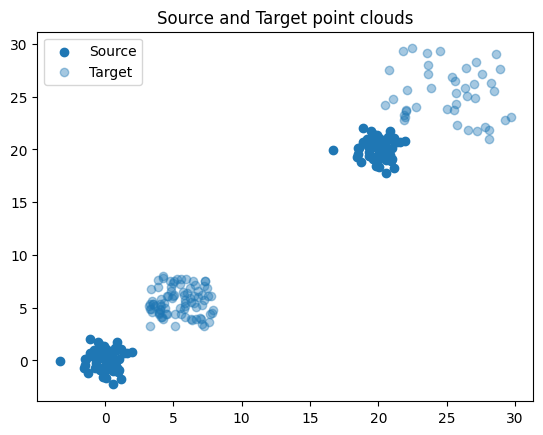

In [13]:
alpha_auto = min(0.4, 100 / n)  # adjust the alpha to the number of points
plt.scatter(x[:, 0], x[:, 1], label="Source", color="#1f77b4", alpha=1)
plt.scatter(y[:, 0], y[:, 1], label="Target", color="#1f77b4", alpha=alpha_auto)
plt.legend()
plt.title("Source and Target point clouds")
plt.show()

## 3. Low-rank partitions with ott-jax LRSinkhorn



### Why a low-rank OT solver?

`LRSinkhorn` implements the low-rank optimal transport (OT) formulation introduced by Scetbon *et al.* (2021). Instead of searching over all admissible $n\times m$ transport matrices, we restrict attention to matrices that factorize as

$$
P_r \;=\; Q\,\mathrm{diag}\bigl(1/g\bigr)\,R^\top,
$$

where:

- **$r$** is the **rank of the approximation**, i.e., the number of intermediate clusters used to represent the transport plan.  
  It controls the trade-off between **accuracy and efficiency**. This rank defines the number of columns in $Q$ and $R$, and the dimension of the vector $g$.

- $Q \in \mathbb{R}^{n \times r}$ is the **soft-cluster assignment matrix of source points**.  
  It assigns each **source point** (each row) to a mixture over $r$ intermediate clusters and determines how much of the source point’s mass is routed through each of the intermediate clusters. So, $Q_{i,z}$ represents **the proportion of mass from source point $i$** that is assigned to cluster $z$.

- Similarly, the matrix $R \in \mathbb{R}^{m \times r}$ is the **soft-cluster assignment of target points**. It assigns each **target point** to a mixture over the same $r$ clusters and determines how much of the incoming mass to target point $j$ comes from cluster $z$. This allows the source and target distributions to be connected via shared intermediate hubs.

- The vector $g \in \Delta^r$ is a probability distribution over the $r$ clusters.  
It controls **how much total mass** flows through each cluster and determines the relative importance of each cluster in the overall transport. In many implementations, such as `HiRef`, $g$ is fixed to be uniform (i.e., $g_z = 1/r$).

For small rank $r$, this reduces memory complexity to $\mathcal{O}\bigl((n + m)\,r\bigr)$ and enables log-linear runtimes.

### Uniform $g$ and rank $=2$ in `HiRef`

`HiRef` builds on that idea: if $g$ can be kept uniform, every column of $Q$ perfectly "co-clusters" a set of source points with the corresponding column of $R$ on the target side; recursing on each block yields a bijective Monge map in $O(n\log n)$ time.

Especially, **Proposition 3.1** of Halmos *et al.* proves that if $ g = \left(\frac{1}{2}, \frac{1}{2}\right) $ and $ r = 2 $,  thus the maximisers of $Q$ and $R$ partition $X$ and $Y$ into two subsets that are perfectly matched by the Monge map $T^*(x)$.

The original paper enforces uniformity of the vector $g$ by letting a KL-penalty $\tau \to \infty$.

However `OTT-JAX 0.5.0` does not expose $\tau$, but we can mimic the same constraint with:

- A large $\gamma$ – this shrinks the mirror-descent step on $g$, so it moves very slowly away from its initial uniform value.
- A floor $\text{min\_value} \approx \frac{1}{r}$ inserted through `kwargs_dys`, which Dykstra applies after every update, preventing any $g_k$ from dropping below the uniform target.



### Configuring LRSinkhorn for HiRef

- `rank=2` – enforces two sub-blocks per level.

- `gamma=1e5` – drives $g$ towards $(\tfrac{1}{2}, \tfrac{1}{2})$ without numerical blow-ups

- `gamma_rescale=True` – rescales $\gamma$ internally each iteration, improving gradient conditioning on difficult costs 

- `kwargs_dys={'min_entry_value': 0.49}` – places a floor slightly below $1/r$ to stop any row of $Q$ or $R$ collapsing, which would violate the HiRef invariant.

- `lse_mode=True` – performs updates in log-space, preventing overflow when $\gamma$ is huge

- `jax.jit` – compiles the solver once; subsequent calls run at native XLA speed, amortizing cost across HiRef’s many recursive partitions.


In [14]:
# 2) instanciation du solver low-rank avec borne KL
rank = 2

base_solver = LRSinkhorn(
    rank          = 2,
    gamma         = 1e5,                
    gamma_rescale = True,
    kwargs_dys    = {"min_entry_value":0.49},     
    lse_mode      = True
)

solver_jit  = jax.jit(base_solver)

In [15]:
def low_rank_partition(x_block: jnp.ndarray,
                       y_block: jnp.ndarray,
                       solver: Callable = solver_jit):
    """
    Renvoie labels_x, labels_y, (Q,R,g) en appelant solver(ot_prob).
    """
    # 1) Créez le geometry correctement
    geom    = pointcloud.PointCloud(x_block, y_block)
    # 2) Instanciez le problème
    ot_prob = linear_problem.LinearProblem(geom)
    # 3) Lancez le solver compilé
    out     = solver(ot_prob)

    Q, R, g = out.q, out.r, out.g

    return Q, R, g

`low_rank_partition` return the 2 low-rank matrices $Q$ , $R$ and the weight vector $g$

In [16]:
Q, R, g = low_rank_partition(x, y)

### Point assignment to a specific partition using `LRSinkhorn` output

The **`LRSinkhorn` algorithm** outputs two low-rank matrices $Q$ and $R$ that approximate the optimal transport plan between a source block $X$ and a target block $Y$.

- Each row of $Q \in \mathbb{R}^{n \times r}$ corresponds to a source point $x_i \in X$.
- Each row of $R \in \mathbb{R}^{m \times r}$ corresponds to a target point $y_j \in Y$.
- The entries in each row of $Q$ and $R$ represent **soft assignments** to $r$ intermediate clusters.

To assign each point to a specific partition (i.e., a hard clustering):

- For each source point $x_i$, we assign it to the cluster index with the highest weight:

  $$
  \ell_X(i) = \arg\max_{z \in \{1, \dots, r\}} Q_{iz}
  $$

- For each target point $y_j$, we similarly assign:

  $$
  \ell_Y(j) = \arg\max_{z \in \{1, \dots, r\}} R_{jz}
  $$

This procedure yields **co-clusterings** of the source and target datasets.  

In the particular case of **$r = 2$** in respect to the **Proposition 3.1** of Halmos *et al.*, the $\arg\max$ assignment produces two matched partitions of $X$ and $Y$ — say $(X_1, X_2)$ and $(Y_1, Y_2)$. These partitions can be recursively refined by the `HiRef` algorithm to construct a full bijective transport map.

More general rank schedules (with $r > 2$) will be explored later in the tutorial.


In [17]:
# 1) Calcul de la partition et extraction des labels
labels_x = jnp.argmax(Q, axis=1)
labels_y = jnp.argmax(R, axis=1)

# 2) Fonction utilitaire pour séparer en deux sous-ensembles
def split_by_label(data, labels, target_label=0):
    """Retourne data[target_label] et data[!= target_label]."""
    mask = labels == target_label
    return data[mask], data[~mask]

# On suppose partition_x et partition_y sont déjà les labels 0/1
x0, x1 = split_by_label(x, labels_x)
y0, y1 = split_by_label(y, labels_y)

### Why Some Partitions Can Be Unbalanced?

In theory, when using `LRSinkhorn` with $r = 2$ and enforcing a **uniform constraint** on $g = (1/2, 1/2)$, the resulting partitions of $X$ and $Y$ — obtained by applying $\arg\max$ to the rows of $Q$ and $R$ — should divide each dataset into two **perfectly balanced** blocks of equal size.

In our `HiRef` implementation, however, we do **not explicitly fix** $g$. Instead, we use a large penalty parameter $\gamma = 10^5$ and apply a **lower bound** on the entries of $g$ by setting `kwargs_dys["min_entry_value"] ≈ 1/r`. This simple trick is usually sufficient to keep the Kullback–Leibler divergence between $g$ and the uniform vector below $10^{-3}$. This low Kullback–Leibler divergence indicates that $g$ stays very close to the uniform distribution $\bigl(\tfrac12,\tfrac12\bigr)$.


In [18]:
kl = jnp.sum(g * jnp.log(g * rank))
print(f"KL(g‖1/r) = {kl:.2e}")
assert kl < 1e-3

KL(g‖1/r) = 3.38e-07


Even though $g$ stays close to uniform, the $\arg\max$ hard assignment of points to clusters can still lead to slightly **unbalanced partitions**, especially if some rows of $Q$ or $R$ are close to uniform (i.e., ties or near-ties between clusters):

In [19]:
print(f"Source split sizes: x0 = {x0.shape}, x1 = {x1.shape}")
print(f"Target split sizes: y0 = {y0.shape}, y1 = {y1.shape}")

Source split sizes: x0 = (64, 2), x1 = (64, 2)
Target split sizes: y0 = (64, 2), y1 = (64, 2)


**Slightly unbalanced partitions** are harmless in practice, and the recursive nature of HiRef continues to produce bijective alignments at the finest scale.


However, if you want to ensure that each partition contains **exactly** $\text{round}(g_k \cdot n)$ points, we provide an alternative hard assignment function: `simple_balanced_partition`. 

This method:
- Respects the target cluster proportions encoded in $g$.

- Assigns each point to its most likely cluster (based on $Q$).

- Enforces **exact cluster sizes** by construction.

- Is useful when you need a **strict bijective alignment** in downstream applications (e.g., deterministic block pairing in `HiRef`).

Using this function instead of vanilla $\arg\max$, gives you **full control** over the size of each partition and can avoid accidental size mismatches during recursive refinement steps.

In [21]:
def simple_balanced_partition(Q: jnp.ndarray, g: jnp.ndarray) -> jnp.ndarray:
    """
    Assigns each point to a cluster such that the final partition is balanced
    according to the target proportions given by g.

    Args:
        Q: Array of shape (n, k) containing assignment scores for each point i and cluster k.
        g: Array of shape (k,) representing the relative weight (target proportion) for each cluster.

    Returns:
        labels: Array of shape (n,) where each entry is an integer in {0, ..., k-1},
                and exactly round(g[k] * n) points are assigned to each cluster k.
    """
    # number of data points, number of clusters
    n, k = Q.shape

    # compute target number of points per cluster (rounded to integers)
    caps = jnp.round(g * n).astype(int)

    # correct for rounding errors to ensure total adds up to n
    diff = n - caps.sum()
    if diff != 0:
        # sort clusters by descending target proportion
        order = jnp.argsort(-g)
        # Add or subtract 1 from top |diff| entries in g
        for idx in order[:abs(diff)]:
            caps = caps.at[idx].add(jnp.sign(diff))

    # prepare output: -1 means “unassigned” initially
    labels = -jnp.ones(n, dtype=int)
    # track which points have been assigned
    assigned = jnp.zeros(n, dtype=bool)

    # assign clusters in order of descending target weight
    for cluster in jnp.argsort(-g):
        # consider only points not yet assigned
        rem = jnp.where(~assigned)[0]
        # get their scores for this cluster
        scores_rem = Q[rem, cluster]
        # sort remaining points by descending score
        order_rem = rem[jnp.argsort(-scores_rem)]
        # pick top cap[cluster] points for this cluster
        chosen = order_rem[: caps[cluster]]
        # record their cluster labels
        labels = labels.at[chosen].set(cluster)
        # mark them as assigned
        assigned = assigned.at[chosen].set(True)

    return labels

We can now verify that, following the partition, **all points are successfully assigned** and that each sub-cluster contains exactly the expected number of points in both the source and target datasets based on the proportions in $g$.

In [22]:
# Compute balanced partitions
partition_x = simple_balanced_partition(Q, g)
partition_y = simple_balanced_partition(R, g)

# 1. Assert all points are assigned
assert jnp.all(partition_x >= 0), "Some source points are unassigned"
assert jnp.all(partition_y >= 0), "Some target points are unassigned"

# 2. Check that each cluster has the expected size
n = Q.shape[0]
target_counts = jnp.round(g * n).astype(int)

for k in range(2): #because here rank=2, so we get 2 sub-clusters
    count_x = jnp.sum(partition_x == k)
    count_y = jnp.sum(partition_y == k)
    assert count_x == target_counts[k], f"X partition for cluster {k} is incorrect"
    assert count_y == target_counts[k], f"Y partition for cluster {k} is incorrect"
    print(f"Cluster {k}: X_{k} and Y_{k} each contain {target_counts[k]} points (out of {n} total)")


Cluster 0: X_0 and Y_0 each contain 64 points (out of 128 total)
Cluster 1: X_1 and Y_1 each contain 64 points (out of 128 total)


### Visualizing the Balanced Partition

Once we compute the balanced cluster assignments using `simple_balanced_partition`, we can visualize the resulting co-clustering of the source and target datasets.

In the case where `rank = 2`, the dataset is split into two matched partitions: $(X_0, X_1)$ for the source and $(Y_0, Y_1)$ for the target. Each point is assigned to the cluster for which it had the highest score in $Q$ or $R$, while ensuring that the number of points in each group matches the target proportions defined by $g$.

The figure below shows the two source clusters and their corresponding target clusters. Since we enforced a balanced partition, the cardinalities of $X_0$ and $Y_0$ (and likewise $X_1$ and $Y_1$) are exactly equal. This pairing is a key requirement for `HiRef`, which will recursively align these blocks in subsequent refinement steps.

> The transparency of the target points (controlled by `alpha`) helps distinguish between source and target data especially when overlapping clusters occupy similar regions.

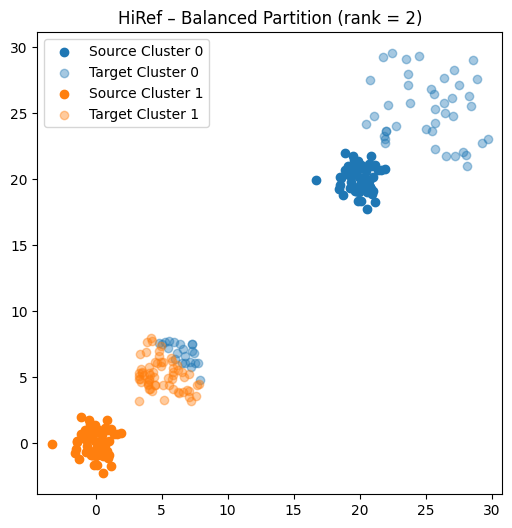

In [23]:
import matplotlib.pyplot as plt

# Balanced labels
partition_x = simple_balanced_partition(Q, g)
partition_y = simple_balanced_partition(R, g)

# Build masks for cluster 0 and 1
mask_x0 = (partition_x == 0)
mask_x1 = ~mask_x0
mask_y0 = (partition_y == 0)
mask_y1 = ~mask_y0

# Automatic alpha based on number of points
n = x.shape[0]

# Use consistent colors across source/target for each cluster
colors = ["tab:blue", "tab:orange"]

plt.figure(figsize=(6, 6))

# Cluster 0: source and target in same color
plt.scatter(x[mask_x0, 0], x[mask_x0, 1], c=colors[0], alpha=1, label=None)
plt.scatter(y[mask_y0, 0], y[mask_y0, 1], c=colors[0], alpha=alpha_auto, label=None)
plt.scatter([], [], c=colors[0], alpha=1.0, label="Source Cluster 0")
plt.scatter([], [], c=colors[0], alpha=0.4, label="Target Cluster 0")

# Cluster 1
plt.scatter(x[mask_x1, 0], x[mask_x1, 1], c=colors[1], alpha=1, label=None)
plt.scatter(y[mask_y1, 0], y[mask_y1, 1], c=colors[1], alpha=alpha_auto, label=None)
plt.scatter([], [], c=colors[1], alpha=1.0, label="Source Cluster 1")
plt.scatter([], [], c=colors[1], alpha=0.4, label="Target Cluster 1")

plt.legend()
plt.title("HiRef – Balanced Partition (rank = 2)")
plt.axis("equal")
plt.show()

## 4. Building the `HiRef` Function: Recursive Hierarchical Refinement

The `HiRef` function implements the core recursion loop of the **HiRef algorithm**, progressively refining the matching between two datasets `x` and `y` by solving low-rank optimal transport problems at multiple scales. It returns a list of matched index pairs `(i, j)`. These pairs represent a **final bijective alignment** between the datasets, built through recursive co-clustering and refinement.

The input blocks are split into `rank` co-clusters using `low_rank_partition`. Depending on the value of the `balanced_partition` flag:

- If `True`, the split is performed using `simple_balanced_partition`, ensuring that each sub-block contains exactly the expected number of points. 
*Note: this option is **computationally more expensive**, as it requires explicit selection logic rather than simple thresholding.*


- If `False`, a standard $\arg\max$ assignment is used to assign each point to its most likely cluster.

If either `x` or `y` has fewer points than `base_size`, the recursion stops.  
When `balanced_partition=True`, the two blocks are always of equal size, so the base case will yield one-to-one assignments between equally sized sub-blocks.

For each cluster $z \in \{0, \dots, r-1\}$ if the corresponding sub-block in `x` or `y` is empty, it is skipped. Otherwise, the function recurses on the sub-blocks `x_z` and `y_z`, propagating their corresponding indices. The matched pairs returned from all recursive calls are aggregated into a growing list.

### Key Parameters

- The `rank` parameter controls how many sub-blocks each dataset is split into at every step. For example, `rank=2` (as used in the original HiRef paper) creates a binary tree of recursive refinements.

- The `base_size` sets the minimum number of points required to continue splitting. Once a block gets too small, the recursion stops and a final match is created.

- If `balanced_partition=True`, the source and target blocks are always split into sub-groups of exactly the same size. This is important when you want to maintain a **bijective mapping** between the datasets throughout the hierarchy.


In [24]:
def hiref(x: jnp.ndarray,
          y: jnp.ndarray,
          x_idx: jnp.ndarray = None,
          y_idx: jnp.ndarray = None,
          rank: int = 2,
          base_size: int = 1,
          balanced_partition=False):
    """
    Hierarchical Refinement: returns a list of (i,j) pairs
    where i,j are indices into the original datasets.
    """
    # 0) Initialize original indices
    if x_idx is None:
        x_idx = jnp.arange(x.shape[0])
    if y_idx is None:
        y_idx = jnp.arange(y.shape[0])

    n_x, n_y = x.shape[0], y.shape[0]

    # 1) Base case: both blocks are small enough
    if n_x <= base_size or n_y <= base_size:
        return [(int(x_idx[0]), int(y_idx[0]))]

    # 2) Low-rank partition (rank=2)
    Q, R, g = low_rank_partition(x, y, solver_jit)

    if balanced_partition == True:
        lab_x = simple_balanced_partition(Q, g)
        lab_y = simple_balanced_partition(R, g)
    
    else:
        lab_x = jnp.argmax(Q, axis=1)
        lab_y = jnp.argmax(R, axis=1)

    pairs = []
    # 3) Recurse on each cluster z
    for z in range(rank):
        mask_x    = (lab_x == z)
        mask_y    = (lab_y == z)
        x_sub     = x[mask_x]
        y_sub     = y[mask_y]

        # 3a) Skip any empty sub-block
        if x_sub.shape[0] == 0 or y_sub.shape[0] == 0:
            continue

        x_idx_sub = x_idx[mask_x]
        y_idx_sub = y_idx[mask_y]

        # 3b) Recurse
        pairs.extend(hiref(
            x_sub, y_sub,
            x_idx=x_idx_sub,
            y_idx=y_idx_sub,
            rank=rank,
            base_size=base_size,
            balanced_partition = balanced_partition
        ))

    return pairs

The final output is a list of index pairs `(i, j)`, where each `i` refers to a point in the original dataset `x`, each `j` to a point in `y`, and together they define a **global bijection** between the two datasets, constructed recursively.

In [25]:
rng = jax.random.key(4)
n, d = 32, 2
x, y = create_points(rng, n=n, d=d)

# Example usage:
pairs = hiref(x, y, balanced_partition=False) 
print(pairs)

[(7, 30), (15, 29), (8, 21), (2, 13), (1, 10), (6, 22), (11, 31), (12, 24), (14, 26), (13, 14), (9, 25), (3, 28), (4, 18), (5, 23), (0, 12), (10, 19), (24, 27), (29, 11), (30, 17), (25, 20), (18, 15), (19, 16), (28, 3), (23, 4), (31, 5), (27, 0), (22, 6), (17, 1), (21, 7), (20, 8), (16, 2), (26, 9)]


### Constructing the Bijective Transport Matrix

Once the list of matched index pairs `(i, j)` has been computed by `HiRef`, we can build the corresponding **binary transport matrix** $P \in \{0, 1\}^{N \times N}$, where $P_{ij} = 1$ indicates that point $x_i$ is matched to $y_j$.

The matrix is initialized with zeros and updated entry by entry using the matched pairs. When `balanced_partition=False` (the default), the partitions may be slightly unbalanced, and some points may remain unmatched — resulting in rows or columns of $P$ that contain only zeros.

To assess the coverage of the matching, we can compute the percentage of points that were actually transported.


In [26]:
# Build the bijective transport matrix P ∈ {0,1}^{N×N}
N = x.shape[0]
P = jnp.zeros((N, N), dtype=jnp.int32)
for i, j in pairs:
    P = P.at[i, j].set(1)

print("Percentage of points successfully matched:", P.sum(axis=1).sum()/N*100)

Percentage of points successfully matched: 100.0


In the bijective case, with `balanced_partition=True` each row and column should contain exactly one nonzero element, meaning that every point in the source is transported to exactly one target point and vice versa.

We can verify this by checking that the row and column sums are all equal to 1, and print the percentage of transported points to confirm completeness of the matching (percentage should be equal to 100%).

In [27]:
# Example usage:
pairs = hiref(x, y, balanced_partition=True) # Attention par défault balanced_partition=False --> donc on perd des points dans le transport !!!

N = x.shape[0]
P = jnp.zeros((N, N), dtype=jnp.int32)
for i, j in pairs:
    P = P.at[i, j].set(1)

# Verify each row and column sums to 1
assert jnp.all(P.sum(axis=1) == 1)
assert jnp.all(P.sum(axis=0) == 1)

print(f"Percentage of points successfully matched: {P.sum() / N * 100:.2f}%")

Percentage of points successfully matched: 100.00%


### Computing the Transport Cost

We compute the pairwise squared Euclidean distances between all points in `x` and `y` to form the cost matrix $C_{ij} = \|x_i - y_j\|^2$. Then, using the binary transport matrix $P$, we extract the total transport cost as the sum of $P_{ij} \cdot C_{ij}$ over all matched pairs.

The result gives us the **total cost** of transporting points according to the current plan. Dividing by the number of matched points $N$ yields the **average cost per transported point** (a.k.a the average transport cost per unit mass).


In [28]:
# Compute the cost matrix C_{ij} = ||x_i - y_j||²
C = jnp.sum((x[:, None, :] - y[None, :, :]) ** 2, axis=-1)

# Compute the total transport cost using the binary transport matrix P
transport_cost = jnp.sum(P * C)

# Display the total and per-point transport costs
print("Total transport cost:", transport_cost)
print("Average cost per transported point:", jnp.round(transport_cost / N, 2))


Total transport cost: 3396.123
Average cost per transported point: 106.13


To benchmark HiRef against OTT-JAX’s standard solvers, we compare the average transport cost per point. On our dataset, HiRef achieves **106.13**, outperforming full-rank Sinkhorn’s **126.17** and dramatically undercutting low-rank Sinkhorn’s **381.32**.

This superior performance stems from HiRef’s ability to produce a bijective alignment—guaranteeing a one-to-one matching—whereas classic Sinkhorn only yields a regularized (soft) coupling, and the low-rank solver sacrifices accuracy for speed. By iteratively refining coarse couplings, HiRef marries the efficiency of low-rank methods with the precision of full-rank OT, yielding sharper, more faithful matchings. Embedding HiRef in your pipeline delivers near–optimal transport quality at a fraction of the computational cost.

In [ ]:
import jax.numpy as jnp
from ott.geometry.pointcloud import PointCloud                             
from ott.problems.linear.linear_problem import LinearProblem                
from ott.solvers.linear.sinkhorn import Sinkhorn                            
from ott.solvers.linear.sinkhorn_lr import LRSinkhorn                     


# 1. Full Sinkhorn (entropic OT)

# Build a point‐cloud geometry (squared Euclidean cost)
geom = PointCloud(x, y)                        

# Pack geometry into a linear OT problem (uniform marginals by default)
ot_problem = LinearProblem(geom)                                        

# Create and run the Sinkhorn solver
solver_full = Sinkhorn()
out_full = solver_full(ot_problem)                                         

# Extract the entropic regularized cost
cost_sinkhorn = out_full.reg_ot_cost
print("Sinkhorn cost:", cost_sinkhorn)


# 2. Low-Rank Sinkhorn

# Reuse the same OT problem for low-rank solver
solver_lr = LRSinkhorn(rank=int(min(x.shape[0], y.shape[0]) / 2),
                       epsilon=1e-3,
                       max_iterations=500)

out_lr = solver_lr(ot_problem)                                            
# You can inspect either the primal cost or the reg. cost:
cost_lr = out_lr.primal_cost
print("Low-Rank Sinkhorn cost:", cost_lr)


Sinkhorn cost: 126.16701
Low-Rank Sinkhorn cost: 381.32318


## 5. Visualizing Multiscale Alignments

The figure below illustrates the bijective matching computed by `HiRef`, where each arrow connects a source point to its assigned target. One striking feature of the visualization is that **no arrows cross** — a hallmark of the Monge map structure that `HiRef` approximates. This reflects the fact that the algorithm preserves spatial locality: in most cases, each source point is matched to the **nearest target point within its corresponding sub-cluster**.

Overall, the transport appears smooth and well-structured, with minimal long-distance assignments. This demonstrates that `HiRef` not only produces a valid bijection but also captures the underlying geometry of the point clouds.


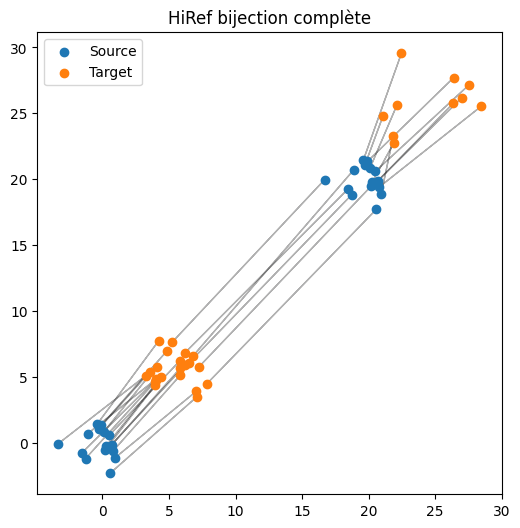

In [30]:
plt.figure(figsize=(6,6))
for i, j in pairs:
    plt.arrow(x[i,0], x[i,1],
              y[j,0] - x[i,0],
              y[j,1] - x[i,1],
              head_width=0.05, alpha=0.3, length_includes_head=True)
plt.scatter(x[:,0], x[:,1], c='C0', label='Source')
plt.scatter(y[:,0], y[:,1], c='C1', label='Target')
plt.legend(); plt.title("HiRef bijection complète"); plt.show()